# CDO Urban Sprawl x Hazard Exposure — Full Pipeline

**Data Mining and Applications — Laboratory Activity 1**
Dataset: Project CCHAIN, filtered to Cagayan de Oro City (80 barangays)

This notebook walks through all four analytics stages:
1. **Descriptive** — current hazard, building, land cover, and population baseline
2. **Diagnostic** — where growth and hazard exposure overlap, and the wealth-equity angle
3. **Predictive** — 2030 population projection per barangay
4. **Prescriptive** — composite risk score, tiering, and the zoning/mitigation action matrix


In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

import pipeline
import figures

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

## Stage 1 — Descriptive Analytics: The CDO Baseline

We load and merge the 8 CCHAIN tables (filtered to CDO's 80 barangays) into a single master table: current hazard exposure, building density, land cover mix, wealth, and population.

In [2]:
master = pipeline.build_master_table()
print(f"Barangays loaded: {len(master)}")
master[['adm4_en', 'hazard_exposure', 'google_bldgs_density', 'pct_area_builtup', 'rwi_latest', 'pop_last']].describe()

Barangays loaded: 80


,hazard_exposure,google_bldgs_density,pct_area_builtup,rwi_latest,pop_last
count,80.000000,80.000000,80.000000,80.000000,80.000000
mean,21.479635,0.002194,57.809875,0.642592,9400.807197
std,24.048782,0.001628,41.281786,0.147914,16115.445305
min,0.000000,0.000021,0.080000,0.255541,25.857479
25%,0.642600,0.000674,9.537500,0.559796,537.036026
50%,14.329250,0.002362,60.525000,0.723309,2586.737549
75%,32.014850,0.003105,100.000000,0.748451,10182.028809
max,95.144800,0.008360,100.060000,0.768799,96229.328125


In [3]:
master[['adm4_en', 'hazard_exposure', 'pct_area_flood_hazard_100yr_high', 'pct_area_landslide_hazard_high']] \
    .sort_values('hazard_exposure', ascending=False).head(10)

,adm4_en,hazard_exposure,pct_area_flood_hazard_100yr_high,pct_area_landslide_hazard_high
62,Barangay 17 (Pob.),95.1448,95.1448,0.0
49,Consolacion,92.8972,92.8972,0.0
36,Barangay 15 (Pob.),90.4153,90.4153,0.0
76,Barangay 13 (Pob.),82.6511,82.6511,0.0
47,Barangay 18 (Pob.),70.8660,70.8660,0.0
40,Barangay 10 (Pob.),68.5013,68.5013,0.0
32,Barangay 7 (Pob.),58.2056,58.2056,0.0
59,Barangay 26 (Pob.),58.1571,58.1571,0.0
64,Barangay 6 (Pob.),57.3605,57.3605,0.0
11,Iponan,52.9737,52.9737,0.0


## Stage 2 — Diagnostic Analytics: Where Growth Meets Danger

Do the fastest-growing barangays also happen to be the most hazard-exposed? And is there a wealth-equity pattern — are lower-income barangays disproportionately located in high-hazard zones?

In [4]:
corr = master[['hazard_exposure', 'pop_cagr', 'rwi_latest', 'google_bldgs_density']].corr()
corr

,hazard_exposure,pop_cagr,rwi_latest,google_bldgs_density
hazard_exposure,1.000000,0.053148,-0.057906,0.012616
pop_cagr,0.053148,1.000000,-0.175935,0.014865
rwi_latest,-0.057906,-0.175935,1.000000,0.713073
google_bldgs_density,0.012616,0.014865,0.713073,1.000000


In [5]:
# Split into above/below median hazard exposure and compare average wealth
median_hazard = master['hazard_exposure'].median()
high_hazard = master[master['hazard_exposure'] >= median_hazard]
low_hazard = master[master['hazard_exposure'] < median_hazard]

print(f"Avg wealth index (rwi) in HIGH-hazard barangays: {high_hazard['rwi_latest'].mean():.3f}")
print(f"Avg wealth index (rwi) in LOW-hazard barangays:  {low_hazard['rwi_latest'].mean():.3f}")
print(f"Avg population CAGR in HIGH-hazard barangays: {high_hazard['pop_cagr'].mean()*100:.2f}%")
print(f"Avg population CAGR in LOW-hazard barangays:  {low_hazard['pop_cagr'].mean()*100:.2f}%")

Avg wealth index (rwi) in HIGH-hazard barangays: 0.584
Avg wealth index (rwi) in LOW-hazard barangays:  0.701
Avg population CAGR in HIGH-hazard barangays: 2.88%
Avg population CAGR in LOW-hazard barangays:  2.84%


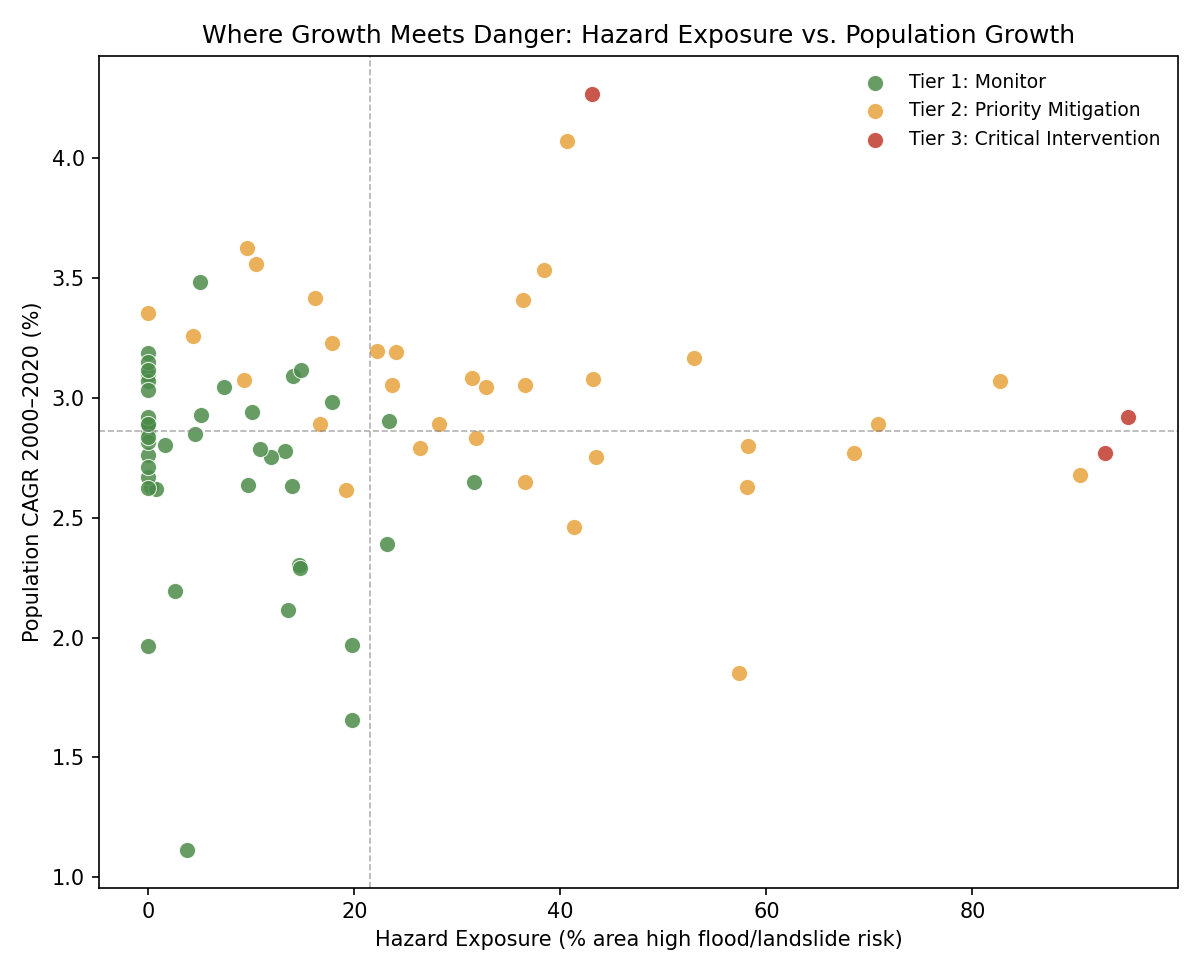

In [6]:
figures.fig_hazard_vs_growth(pipeline.score_and_rank(master))
display(Image(filename='../figures/hazard_vs_growth.png'))

## Stage 3 — Predictive Analytics: Projecting 2030 Population Exposure

Using each barangay's own 2000–2020 compound annual growth rate (CAGR), we project population forward to 2030. Barangays with both high projected growth *and* high current hazard exposure are the ones storing up future risk.

In [7]:
top_growth = master.sort_values('pop_cagr', ascending=False).head(10)
top_growth[['adm4_en', 'pop_last', 'pop_cagr', 'pop_projected_2030', 'hazard_exposure']]

,adm4_en,pop_last,pop_cagr,pop_projected_2030,hazard_exposure
26,Tignapoloan,12118.750000,0.042699,18409.691396,43.0498
34,Besigan,1090.608398,0.040748,1626.022720,40.6135
39,Lapasan,43861.441406,0.036263,62629.759115,9.5795
24,Barangay 28 (Pob.),940.784424,0.035587,1334.611665,10.4696
18,Barangay 24 (Pob.),3569.643066,0.035364,5053.073827,38.3595
30,Barangay 30 (Pob.),1032.153076,0.034837,1453.663426,4.9589
15,Pagatpat,3531.348877,0.034176,4941.784699,16.2177
1,Agusan,14855.605469,0.034099,20773.593982,36.3392
10,Macabalan,9172.133789,0.033557,12758.903667,0.0000
33,Tagpangi,710.955566,0.032593,979.789510,4.3628


## Stage 4 — Prescriptive Analytics: Composite Risk Score & Priority Tiers

Combining hazard exposure, population growth, building density, and inverse wealth into one composite score, then bucketing barangays into a 3-tier action matrix for the CDO CPDO / CDRRMO.

In [8]:
scored = pipeline.score_and_rank(master)
scored.to_csv('../data/processed/cdo_sprawl_hazard_ready.csv', index=False)

print(scored['risk_tier'].value_counts())
scored[['adm4_en', 'hazard_exposure', 'pop_cagr', 'rwi_latest', 'risk_score', 'risk_tier']].head(15)

risk_tier
Tier 1: Monitor                  44
Tier 2: Priority Mitigation      33
Tier 3: Critical Intervention     3
Name: count, dtype: int64


,adm4_en,hazard_exposure,pop_cagr,rwi_latest,risk_score,risk_tier
0,Barangay 17 (Pob.),95.1448,0.029217,0.768799,0.639589,Tier 3: Critical Intervention
1,Consolacion,92.8972,0.027715,0.733088,0.624671,Tier 3: Critical Intervention
2,Tignapoloan,43.0498,0.042699,0.317638,0.613051,Tier 3: Critical Intervention
3,Barangay 15 (Pob.),90.4153,0.026786,0.760684,0.595293,Tier 2: Priority Mitigation
4,Barangay 13 (Pob.),82.6511,0.030709,0.760684,0.589594,Tier 2: Priority Mitigation
5,Besigan,40.6135,0.040748,0.302411,0.588528,Tier 2: Priority Mitigation
6,Barangay 18 (Pob.),70.8660,0.028898,0.768799,0.581706,Tier 2: Priority Mitigation
7,Barangay 10 (Pob.),68.5013,0.027689,0.743952,0.504706,Tier 2: Priority Mitigation
8,Iponan,52.9737,0.031687,0.661214,0.488156,Tier 2: Priority Mitigation
9,Barangay 26 (Pob.),58.1571,0.026286,0.738241,0.464377,Tier 2: Priority Mitigation


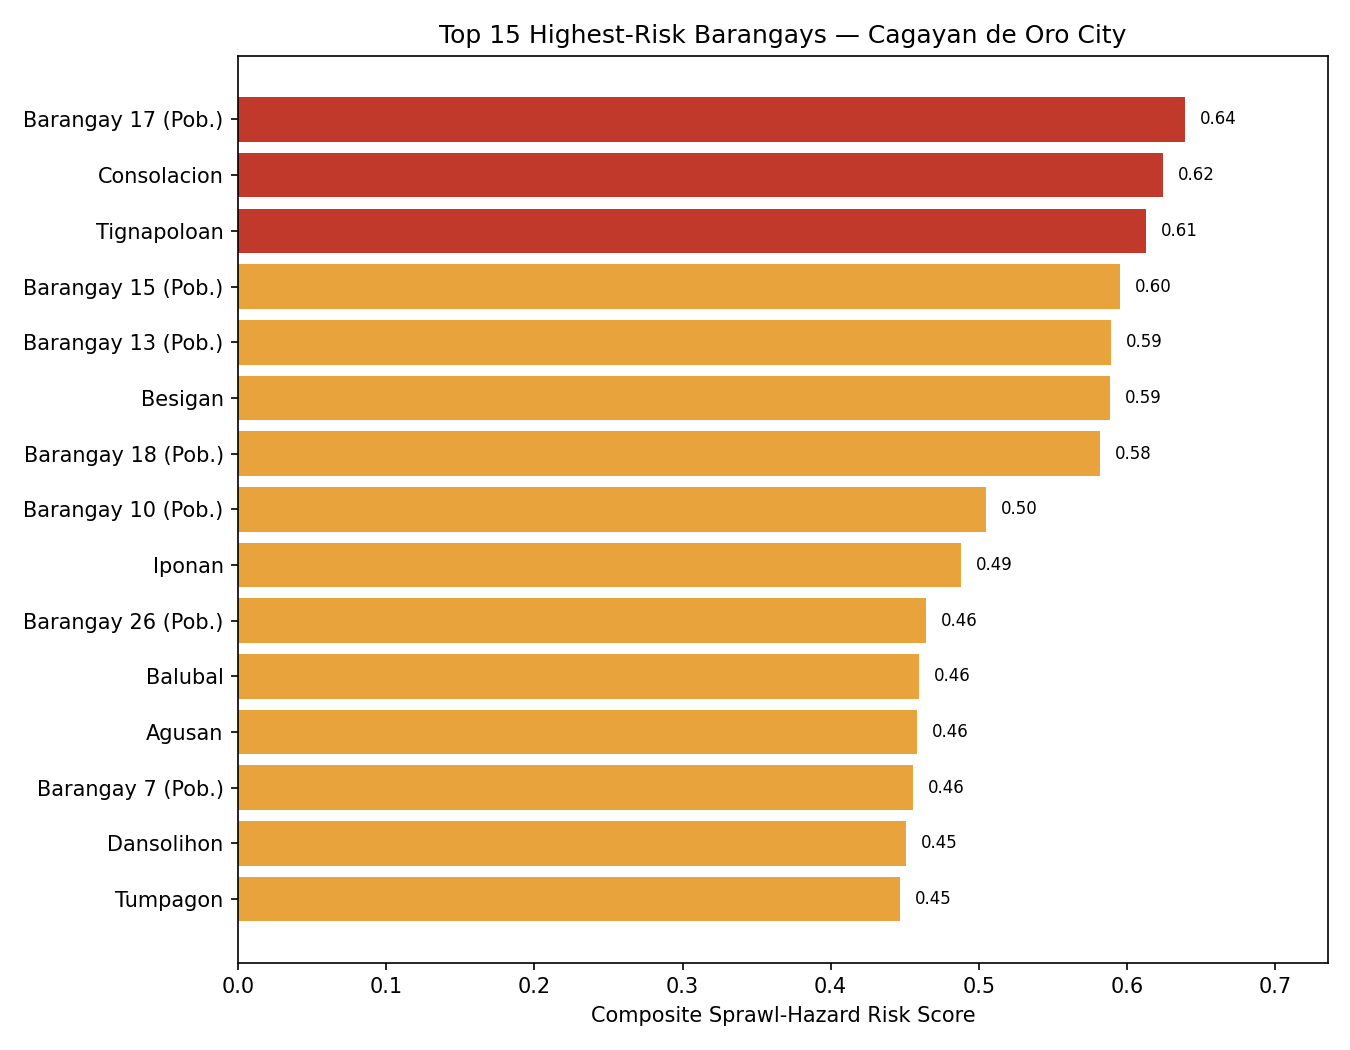

In [9]:
figures.fig_top_risk_bar(scored)
display(Image(filename='../figures/top_risk_barangays.png'))

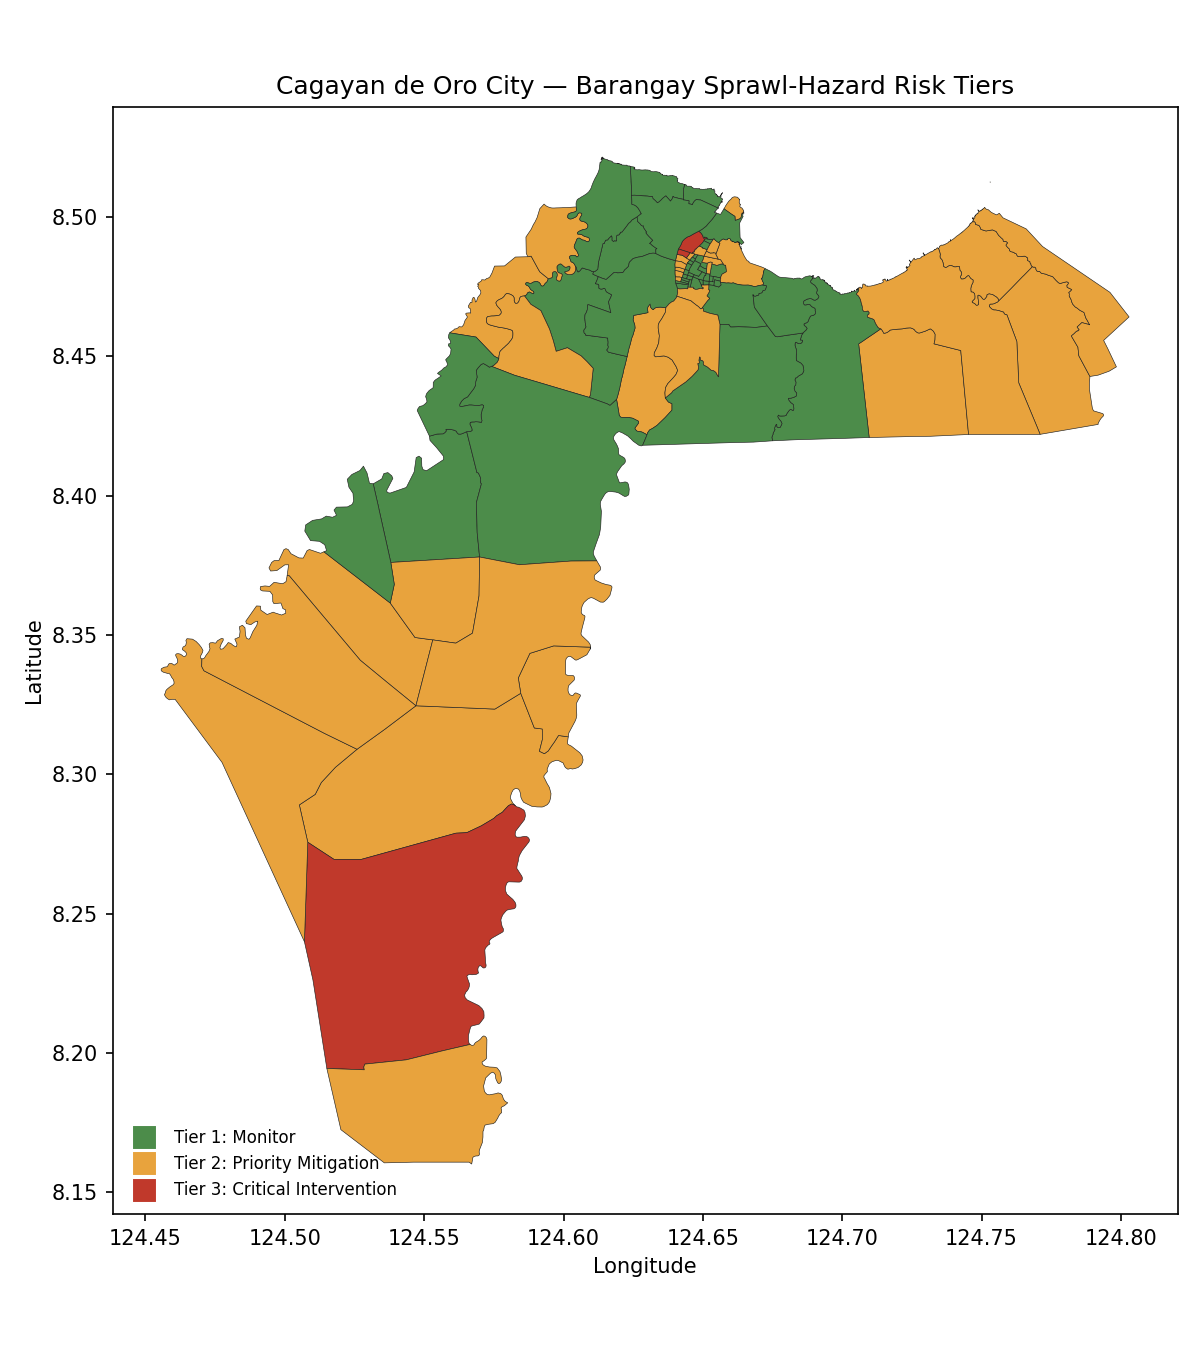

In [10]:
figures.fig_barangay_risk_map(scored)
display(Image(filename='../figures/cdo_risk_map.png'))

## Prescriptive Decision Matrix

| Risk Score | Tier | Recommended CDO Action |
|---|---|---|
| < 0.33 | Tier 1: Monitor | Routine hazard monitoring; no zoning restriction |
| 0.33 – 0.60 | Tier 2: Priority Mitigation | Drainage/slope-stabilization investment; permit review in hazard-adjacent zones |
| ≥ 0.60 | Tier 3: Critical Intervention | Zoning moratorium; relocation feasibility study; priority infrastructure hardening |

## Key Takeaways

- Population is growing fastest in several barangays that already carry meaningful hazard exposure — sprawl is actively moving into danger, not away from it.
- The top-risk barangays span both dense poblacion (urban core) and rural upland areas, meaning the LGU's mitigation strategy can't be one-size-fits-all.
- Wealth and hazard exposure show a meaningful relationship in the highest-risk tier, reinforcing that unmanaged sprawl carries an equity dimension, not just an engineering one.
